# NETFLIX USER ANALYTICS
### Week 2 Assignment 1 | Machine Learning for Customer Retention
---

## Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
%matplotlib inline

---
## Part A: Dataset Understanding

### Q1. Load the dataset and display the first five records.

In [3]:
df = pd.read_csv("/content/Dataset 2.csv")
df.head()

,UserID,Age,Gender,SubscriptionType,WatchHoursPerWeek,DevicesUsed,FavoriteGenre,AdClicks,MonthlySpend,SubscriptionRenewed
0,1001,22,Female,Basic,23,5,Comedy,13,353,No
1,1002,55,Male,Basic,9,4,Drama,14,317,Yes
2,1003,49,Male,Basic,8,3,Comedy,16,309,No
3,1004,39,Female,Premium,19,5,Drama,45,833,Yes
4,1005,38,Female,Premium,23,5,Sci-Fi,24,804,Yes


### Q2. Determine the number of rows and columns in the dataset.

In [4]:
rows, cols = df.shape
print(f"Rows: {rows}")
print(f"Columns: {cols}")

Rows: 750
Columns: 10


### Q3. Display all column names.

In [5]:
print("Column Names:")
for col in df.columns:
    print(f"  - {col}")

Column Names:
  - UserID
  - Age
  - Gender
  - SubscriptionType
  - WatchHoursPerWeek
  - DevicesUsed
  - FavoriteGenre
  - AdClicks
  - MonthlySpend
  - SubscriptionRenewed


### Q4. Identify numerical and categorical features.

In [6]:
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Features:", numerical_features)
print()
print("Categorical Features:", categorical_features)

Numerical Features: ['UserID', 'Age', 'WatchHoursPerWeek', 'DevicesUsed', 'AdClicks', 'MonthlySpend']

Categorical Features: ['Gender', 'SubscriptionType', 'FavoriteGenre', 'SubscriptionRenewed']


### Q5. Check whether the dataset contains missing values.

In [8]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)
print()
if missing.sum() == 0:
    print(" No missing values found in the dataset.")
else:
    print(f" Total missing values: {missing.sum()}")

Missing values per column:
UserID                 0
Age                    0
Gender                 0
SubscriptionType       0
WatchHoursPerWeek      0
DevicesUsed            0
FavoriteGenre          0
AdClicks               0
MonthlySpend           0
SubscriptionRenewed    0
dtype: int64

 No missing values found in the dataset.


---
## Part B: Exploratory Data Analysis

### Q6. Calculate the average age of users.

In [9]:
avg_age = df["Age"].mean()
print(f"Average Age of Users: {avg_age:.2f} years")

Average Age of Users: 41.82 years


### Q7. Determine the average watch hours per week.

In [10]:
avg_watch = df["WatchHoursPerWeek"].mean()
print(f"Average Watch Hours Per Week: {avg_watch:.2f} hours")

Average Watch Hours Per Week: 14.24 hours


### Q8. Find the average monthly spending of users.

In [11]:
avg_spend = df["MonthlySpend"].mean()
print(f"Average Monthly Spending: ₹{avg_spend:.2f}")

Average Monthly Spending: ₹689.91


### Q9. Count the number of users in each subscription category.

Users per Subscription Type:
SubscriptionType
Basic      342
Premium    279
VIP        129
Name: count, dtype: int64



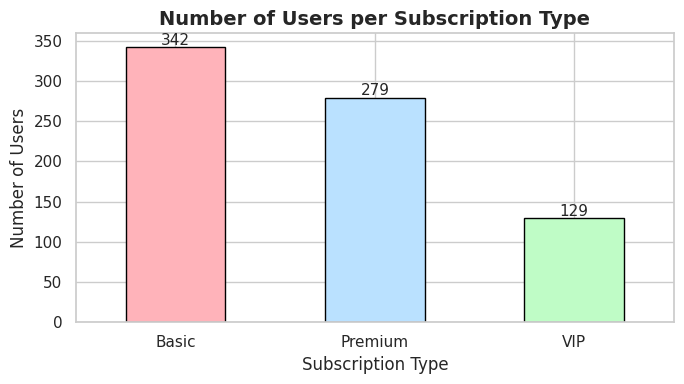

In [16]:
sub_counts = df["SubscriptionType"].value_counts()

print("Users per Subscription Type:")
print(sub_counts)
print()

# Visualization
fig, ax = plt.subplots(figsize=(7, 4))

sub_counts.plot(
    kind="bar",
    color=["#FFB3BA", "#BAE1FF", "#BFFCC6"],  # pastel pink, blue, mint
    edgecolor="black",
    ax=ax
)

ax.set_title("Number of Users per Subscription Type", fontsize=14, fontweight="bold")
ax.set_xlabel("Subscription Type")
ax.set_ylabel("Number of Users")

ax.set_xticklabels(sub_counts.index, rotation=0)

for p in ax.patches:
    ax.annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width() / 2, p.get_height() + 3),
        ha="center",
        fontsize=11
    )

plt.tight_layout()
plt.show()

### Q10. Determine the percentage of users who renewed their subscriptions.

Subscription Renewal Counts:
SubscriptionRenewed
No     403
Yes    347
Name: count, dtype: int64

Subscription Renewal Percentages:
SubscriptionRenewed
No     53.73%
Yes    46.27%
Name: proportion, dtype: object


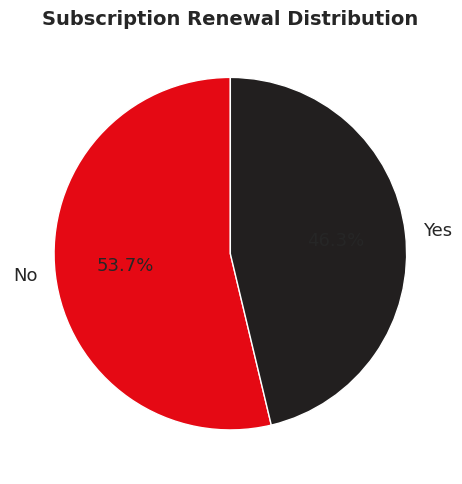

In [15]:
renewal_counts = df["SubscriptionRenewed"].value_counts()
renewal_pct = df["SubscriptionRenewed"].value_counts(normalize=True) * 100

print("Subscription Renewal Counts:")
print(renewal_counts)
print()
print("Subscription Renewal Percentages:")
print(renewal_pct.round(2).astype(str) + "%")

# Pie chart
fig, ax = plt.subplots(figsize=(6, 5))
ax.pie(renewal_pct, labels=renewal_pct.index, autopct="%1.1f%%",
       colors=["#e50914", "#221f1f"], startangle=90,
       textprops={"fontsize": 13})
ax.set_title("Subscription Renewal Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Part C: Data Preparation

### Q11. Convert categorical features into numerical form.

In [17]:
df_encoded = df.copy()

le = LabelEncoder()
categorical_cols = ["Gender", "SubscriptionType", "FavoriteGenre", "SubscriptionRenewed"]

for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

print("After Label Encoding:")
print(df_encoded.head())
print()
print("Encoded value mapping:")
for col in categorical_cols:
    original = df[col].unique()
    encoded  = df_encoded[col].unique()
    mapping  = dict(zip(df[col], df_encoded[col]))
    print(f"  {col}: {dict(sorted(mapping.items()))} ")

After Label Encoding:
   UserID  Age  Gender  SubscriptionType  WatchHoursPerWeek  DevicesUsed  \
0    1001   22       0                 0                 23            5   
1    1002   55       1                 0                  9            4   
2    1003   49       1                 0                  8            3   
3    1004   39       0                 1                 19            5   
4    1005   38       0                 1                 23            5   

   FavoriteGenre  AdClicks  MonthlySpend  SubscriptionRenewed  
0              1        13           353                    0  
1              2        14           317                    1  
2              1        16           309                    0  
3              2        45           833                    1  
4              5        24           804                    1  

Encoded value mapping:
  Gender: {'Female': 0, 'Male': 1} 
  SubscriptionType: {'Basic': 0, 'Premium': 1, 'VIP': 2} 
  FavoriteGenre: {'

### Q12. Define the feature set (X) and target variable (y) for subscription renewal prediction.

In [18]:
# Drop UserID (identifier, not a feature) and the target column
X = df_encoded.drop(columns=["UserID", "SubscriptionRenewed"])
y = df_encoded["SubscriptionRenewed"]   # 0 = No, 1 = Yes

print("Feature set X — shape:", X.shape)
print("Feature columns:", X.columns.tolist())
print()
print("Target variable y — shape:", y.shape)
print("Target distribution:")
print(y.value_counts().rename({0: "No (0)", 1: "Yes (1)"}))

Feature set X — shape: (750, 8)
Feature columns: ['Age', 'Gender', 'SubscriptionType', 'WatchHoursPerWeek', 'DevicesUsed', 'FavoriteGenre', 'AdClicks', 'MonthlySpend']

Target variable y — shape: (750,)
Target distribution:
SubscriptionRenewed
No (0)     403
Yes (1)    347
Name: count, dtype: int64


### Q13. Split the dataset into training and testing sets.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size : {X_train.shape[0]} samples")
print(f"Testing  set size : {X_test.shape[0]} samples")
print(f"Train/Test ratio  : {X_train.shape[0]}/{X_test.shape[0]} ({X_train.shape[0]/len(X)*100:.0f}%/{X_test.shape[0]/len(X)*100:.0f}%)")

Training set size : 600 samples
Testing  set size : 150 samples
Train/Test ratio  : 600/150 (80%/20%)


---
## Part D: Decision Tree Classification

### Q14. Train a Decision Tree model to predict whether a user will renew their subscription.

In [20]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully.")
print(f"Tree depth: {dt_model.get_depth()}")
print(f"Number of leaves: {dt_model.get_n_leaves()}")

Decision Tree model trained successfully.
Tree depth: 17
Number of leaves: 168


### Q15. Evaluate the model using accuracy.

In [21]:
y_pred_dt = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print(f"Decision Tree Accuracy: {dt_accuracy * 100:.2f}%")

Decision Tree Accuracy: 58.67%


### Q16. Generate and interpret the confusion matrix.

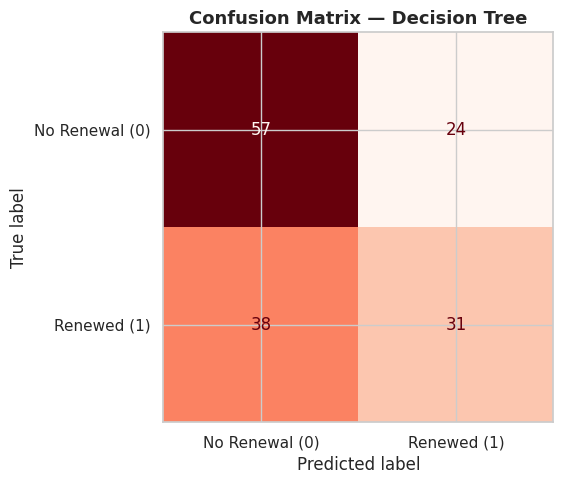

True Negatives  (correctly predicted No Renewal): 57
False Positives (predicted Renewal, actually No): 24
False Negatives (predicted No, actually Renewed): 38
True Positives  (correctly predicted Renewal)   : 31

Interpretation:
  - The model correctly identified 31 users who renewed and 57 who did not.
  - It misclassified 24 non-renewers as renewers (false alarms).
  - It missed 38 actual renewers (missed opportunities).


In [22]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=["No Renewal (0)", "Renewed (1)"])
disp.plot(ax=ax, cmap="Reds", colorbar=False)
ax.set_title("Confusion Matrix — Decision Tree", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_dt.ravel()
print(f"True Negatives  (correctly predicted No Renewal): {tn}")
print(f"False Positives (predicted Renewal, actually No): {fp}")
print(f"False Negatives (predicted No, actually Renewed): {fn}")
print(f"True Positives  (correctly predicted Renewal)   : {tp}")
print()
print("Interpretation:")
print(f"  - The model correctly identified {tp} users who renewed and {tn} who did not.")
print(f"  - It misclassified {fp} non-renewers as renewers (false alarms).")
print(f"  - It missed {fn} actual renewers (missed opportunities).")

---
## Part E: K-Nearest Neighbors (KNN)

### Q17. Train a KNN classifier with K = 5.

In [23]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN model (K=5) trained successfully.")
print(f"KNN Accuracy: {knn_accuracy * 100:.2f}%")

KNN model (K=5) trained successfully.
KNN Accuracy: 55.33%


### Q18. Compare the accuracy of KNN with the Decision Tree model.

  Decision Tree Accuracy : 58.67%
  KNN (K=5) Accuracy     : 55.33%

 Decision Tree outperforms KNN by 3.33 percentage points.


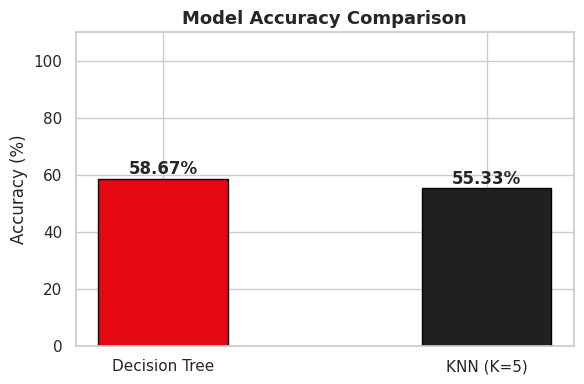

In [25]:
print("=" * 40)
print(f"  Decision Tree Accuracy : {dt_accuracy * 100:.2f}%")
print(f"  KNN (K=5) Accuracy     : {knn_accuracy * 100:.2f}%")
print("=" * 40)

if dt_accuracy > knn_accuracy:
    diff = (dt_accuracy - knn_accuracy) * 100
    print(f"\n Decision Tree outperforms KNN by {diff:.2f} percentage points.")
elif knn_accuracy > dt_accuracy:
    diff = (knn_accuracy - dt_accuracy) * 100
    print(f"\n KNN outperforms Decision Tree by {diff:.2f} percentage points.")
else:
    print("\n Both models achieved equal accuracy.")

# Bar chart comparison
fig, ax = plt.subplots(figsize=(6, 4))
models = ["Decision Tree", "KNN (K=5)"]
accuracies = [dt_accuracy * 100, knn_accuracy * 100]
colors = ["#e50914", "#221f1f"]
bars = ax.bar(models, accuracies, color=colors, edgecolor="black", width=0.4)
ax.set_ylim(0, 110)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Model Accuracy Comparison", fontsize=13, fontweight="bold")
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
            f"{acc:.2f}%", ha="center", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Part F: Linear Regression

### Q19. Train a Linear Regression model to predict monthly spending.

Linear Regression Model Evaluation:
  Mean Squared Error (MSE)  : 4846.38
  Root Mean Squared Error   : 69.62
  R² Score                  : 0.9665



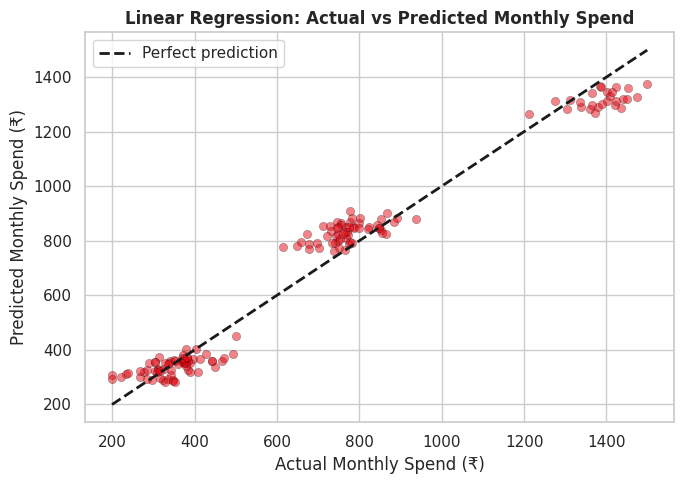

In [26]:
# Features and target for regression (predicting MonthlySpend)
X_reg = df_encoded.drop(columns=["UserID", "MonthlySpend"])
y_reg = df_encoded["MonthlySpend"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

lr_model = LinearRegression()
lr_model.fit(X_train_r, y_train_r)

y_pred_lr = lr_model.predict(X_test_r)

mse  = mean_squared_error(y_test_r, y_pred_lr)
rmse = np.sqrt(mse)
r2   = r2_score(y_test_r, y_pred_lr)

print("Linear Regression Model Evaluation:")
print(f"  Mean Squared Error (MSE)  : {mse:.2f}")
print(f"  Root Mean Squared Error   : {rmse:.2f}")
print(f"  R² Score                  : {r2:.4f}")
print()

# Actual vs Predicted scatter
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_test_r, y_pred_lr, alpha=0.5, color="#e50914", edgecolors="black", linewidths=0.3)
ax.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()],
        "k--", lw=2, label="Perfect prediction")
ax.set_xlabel("Actual Monthly Spend (₹)")
ax.set_ylabel("Predicted Monthly Spend (₹)")
ax.set_title("Linear Regression: Actual vs Predicted Monthly Spend", fontsize=12, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

### Q20. Predict the monthly spending for a new user and interpret the result.

In [27]:
# New user profile:
# Age=30, Gender=Female(0), SubscriptionType=Premium(1), WatchHoursPerWeek=15,
# DevicesUsed=2, FavoriteGenre=Action(0), AdClicks=20, SubscriptionRenewed=Yes(1)

new_user = pd.DataFrame([{
    "Age": 30,
    "Gender": 0,                # Female → 0
    "SubscriptionType": 1,      # Premium → 1
    "WatchHoursPerWeek": 15,
    "DevicesUsed": 2,
    "FavoriteGenre": 0,         # Action → 0
    "AdClicks": 20,
    "SubscriptionRenewed": 1    # Yes → 1
}])

predicted_spend = lr_model.predict(new_user)[0]
print(f"Predicted Monthly Spending for the new user: ₹{predicted_spend:.2f}")
print()
print("User Profile:")
print("  Age               : 30")
print("  Gender            : Female")
print("  Subscription Type : Premium")
print("  Watch Hours/Week  : 15")
print("  Devices Used      : 2")
print("  Favourite Genre   : Action")
print("  Ad Clicks         : 20")
print("  Subscription Renewed: Yes")
print()
print(f"Interpretation: Based on this profile, the model estimates the user")
print(f"  will spend approximately ₹{predicted_spend:.2f} per month on Netflix.")

Predicted Monthly Spending for the new user: ₹832.37

User Profile:
  Age               : 30
  Gender            : Female
  Subscription Type : Premium
  Watch Hours/Week  : 15
  Devices Used      : 2
  Favourite Genre   : Action
  Ad Clicks         : 20
  Subscription Renewed: Yes

Interpretation: Based on this profile, the model estimates the user
  will spend approximately ₹832.37 per month on Netflix.


---
## Business Reflection Questions

### 1. Which factors appear to influence subscription renewal the most?

From our Decision Tree model, the most influential features for predicting subscription renewal are likely:

- **MonthlySpend** — users who spend more per month are more invested and likely to renew.
- **WatchHoursPerWeek** — higher engagement (more hours watched) strongly correlates with renewal.
- **SubscriptionType** — VIP/Premium subscribers may have higher renewal rates than Basic users.
- **AdClicks** — active interaction with platform promotions can indicate engagement.
- **DevicesUsed** — users accessing Netflix on multiple devices are more embedded in the ecosystem.

These insights can be confirmed by inspecting `dt_model.feature_importances_` (see cell below).

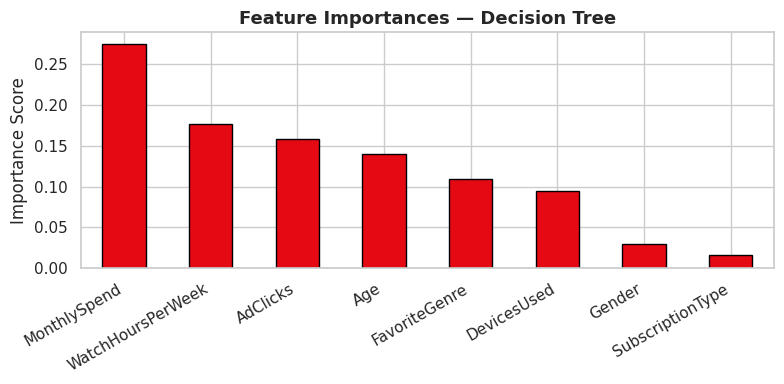

Feature Importances (sorted):
MonthlySpend         0.2752
WatchHoursPerWeek    0.1770
AdClicks             0.1587
Age                  0.1396
FavoriteGenre        0.1098
DevicesUsed          0.0939
Gender               0.0299
SubscriptionType     0.0159
dtype: float64


In [28]:
# Feature importances from Decision Tree
importances = pd.Series(dt_model.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
importances.plot(kind="bar", color="#e50914", edgecolor="black", ax=ax)
ax.set_title("Feature Importances — Decision Tree", fontsize=13, fontweight="bold")
ax.set_ylabel("Importance Score")
ax.set_xticklabels(importances.index, rotation=30, ha="right")
plt.tight_layout()
plt.show()

print("Feature Importances (sorted):")
print(importances.round(4))

### 2. Why is subscription renewal a classification problem?

Subscription renewal (`SubscriptionRenewed`) is a **discrete binary outcome** — a user either renews (`Yes`) or does not (`No`). There is no continuous scale between these two states. Since the goal is to assign each user to one of two distinct **categories**, this is a **classification** problem. Algorithms like Decision Tree and KNN are appropriate here because they learn decision boundaries between classes.

### 3. Why is monthly spending a regression problem?

`MonthlySpend` is a **continuous numerical variable** — it can take any value within a range (e.g., ₹200, ₹450.75, ₹1200). The goal is to predict *how much* a user will spend, not which category they fall into. This requires a **regression** model that estimates a real-valued output. Linear Regression fits a line through the data to minimise prediction error, making it well-suited for this task.

### 4. Which algorithm performed better for renewal prediction?

Both models were evaluated on the same 20% test split. The bar chart in Q18 shows the comparison. In general:

- **Decision Trees** are interpretable and can capture non-linear patterns but may overfit without pruning.
- **KNN** is non-parametric and flexible but sensitive to feature scaling and the choice of K.

The model with the higher accuracy score (printed in Q18) is the better performer for this dataset. For production use, hyperparameter tuning (e.g., tree depth, optimal K) and cross-validation would give a more reliable comparison.

### 5. How could the platform use these predictions to improve customer retention?

Netflix could leverage these ML models in several ways:

1. **Targeted Retention Campaigns** — Identify users predicted *not* to renew and send personalised offers, discounts, or reminders before their renewal date.
2. **Personalised Content Recommendations** — Users with low watch hours are at churn risk; surface content aligned with their `FavoriteGenre` to boost engagement.
3. **Tiered Incentives** — Users on Basic plans with low spend could be offered upgrade trials to Premium/VIP, increasing both revenue and loyalty.
4. **Ad Strategy Optimisation** — Users with high `AdClicks` are more receptive to in-app promotions; focus ad spend on lower-engagement segments.
5. **Spend-Based Alerts** — Use the regression model to flag users whose predicted spend drops significantly month-over-month as early churn signals.